# 11 — CIPT Descriptive Analysis v2
## Constraint-Induced Population Theory: flavor archetype framework

**v1 lesson:** Macro entropy (protein/lipid/starch) was the wrong outcome. Macros are set by food *category*
(carb/fat/protein), not terroir. Every region has all three — their ratios don't carry a constraint signal.

**v2 approach:** The right CIPT unit is the **flavor archetype** — which flavor classes does a region's
food system express? Spicy, caffeinated, polyphenol-rich, terpenic, fermented. These are gated by
constraint geometry in the same way D&D class features are gated by minimum stat requirements.

| CIPT Component | D&D | Agriculture (this notebook) |
|---|---|---|
| Constraints C | Stat array, species bonuses | Climate, altitude, soil pH |
| Possibility space X | All valid builds | All flavor archetype combinations |
| Selection B | Player optimization | Fermentation culture, intensification |
| Population π | Build meta distribution | Flavor tradition distribution |

**Hypotheses:**
- **H1:** Higher intensification → lower flavor richness (fewer archetypes per RSU)
- **H4:** Specific constraints gate specific archetypes (constraint bottlenecks)
- **H5:** Similar constraint vectors → similar flavor archetype profiles (Hamming distance)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr, pointbiserialr
from scipy.spatial.distance import cdist

from rsu_loader import load_all_rsus

RCPARAMS = {
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': ':'
}

def sig_stars(p):
    if p is None or (hasattr(p, '__float__') and np.isnan(float(p))): return ''
    p = float(p)
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return 'dag'
    return 'ns'

rsus = load_all_rsus()
print(f'Loaded {len(rsus)} RSUs')

Loaded 65 RSUs


## 1. Constraint Matrix

In [2]:
rows = []
for r in rsus:
    rows.append({
        'region_id':          r.region_id,
        'rsu_name':           r.name,
        'lat':                r.coordinates.lat,
        'altitude_m':         r.coordinates.altitude_m,
        'temp_mean':          r.climate.temperature_mean,
        'temp_seasonality':   r.climate.temperature_seasonality,
        'precip_mean':        r.climate.precipitation_mean,
        'precip_seasonality': r.climate.precipitation_seasonality,
        'soil_pH':            r.geology.soil_pH,
        'fermentation_prev':  r.food_system.fermentation_prevalence,
        'intensification':    r.culture.agricultural_intensification_index,
        'industrial_proc':    r.culture.industrial_processing_index,
    })

C = pd.DataFrame(rows).set_index('region_id')
print(f'Constraint matrix: {C.shape}, complete coverage: {C.notna().all().all()}')
C.drop(columns='rsu_name').describe().round(2)

Constraint matrix: (65, 11), complete coverage: True


,lat,altitude_m,temp_mean,temp_seasonality,precip_mean,precip_seasonality,soil_pH,fermentation_prev,intensification,industrial_proc
count,65.00,65.00,65.00,65.00,65.00,65.00,65.00,65.00,65.00,65.00
mean,22.77,897.69,15.51,13.74,1275.46,0.54,5.98,0.54,0.48,0.39
std,23.13,862.86,7.07,9.82,768.60,0.17,0.95,0.22,0.18,0.17
min,-37.80,10.00,-5.00,1.50,65.00,0.20,4.50,0.05,0.15,0.10
25%,7.50,150.00,11.00,5.00,650.00,0.40,5.20,0.45,0.35,0.25
50%,27.00,700.00,16.00,12.00,1100.00,0.55,5.80,0.55,0.50,0.40
75%,39.00,1500.00,19.00,20.00,1800.00,0.70,6.50,0.70,0.60,0.50
max,64.50,3800.00,28.50,45.00,3000.00,0.85,8.10,0.90,0.98,0.95


## 2. Flavor Archetype Matrix

Binary presence/absence per RSU, across 5 flavor classes.
An RSU has a class if **any** of its staple foods expresses it.
This is the RSU's 'character sheet' — which flavor builds are active.

In [3]:
FLAVOR_COLS = ['spicy', 'caffeinated', 'polyphenol_rich', 'terpenic', 'fermented']

flavor_rows = []
for r in rsus:
    present = set()
    for food in r.staple_foods:
        mp = food.metabolite_profile
        if mp.key_flavor_bioactives.capsaicinoids:
            present.add('spicy')
        if mp.key_flavor_bioactives.caffeine_concentration:
            present.add('caffeinated')
        if mp.key_flavor_bioactives.polyphenol_content:
            present.add('polyphenol_rich')
        if any([mp.terpenes.linalool, mp.terpenes.limonene,
                mp.terpenes.myrcene, mp.terpenes.pinene]):
            present.add('terpenic')
        if mp.organic_acids.lactic_acid or mp.organic_acids.acetic_acid:
            present.add('fermented')
    flavor_rows.append({
        'region_id':       r.region_id,
        'spicy':           int('spicy'           in present),
        'caffeinated':     int('caffeinated'     in present),
        'polyphenol_rich': int('polyphenol_rich' in present),
        'terpenic':        int('terpenic'        in present),
        'fermented':       int('fermented'       in present),
    })

flavor_df = pd.DataFrame(flavor_rows).set_index('region_id')
flavor_df['flavor_richness'] = flavor_df[FLAVOR_COLS].sum(axis=1)
cipt = C.join(flavor_df)

print('Flavor class prevalence (% of RSUs):')
print((flavor_df[FLAVOR_COLS].mean() * 100).round(1).rename('% RSUs').to_string())
print(f"\nFlavor richness: mean = {flavor_df['flavor_richness'].mean():.2f}, "
      f"std = {flavor_df['flavor_richness'].std():.2f}, "
      f"range = {flavor_df['flavor_richness'].min()}–{flavor_df['flavor_richness'].max()}")

Flavor class prevalence (% of RSUs):
spicy              15.4
caffeinated        40.0
polyphenol_rich    80.0
terpenic           52.3
fermented          73.8

Flavor richness: mean = 2.62, std = 1.10, range = 0–5


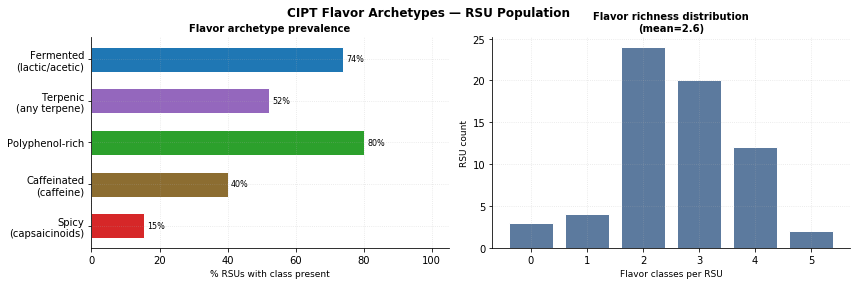

In [4]:
with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    labels = ['Spicy\n(capsaicinoids)', 'Caffeinated\n(caffeine)',
               'Polyphenol-rich', 'Terpenic\n(any terpene)', 'Fermented\n(lactic/acetic)']
    colors = ['#d62728', '#8c6d31', '#2ca02c', '#9467bd', '#1f77b4']
    prev = flavor_df[FLAVOR_COLS].mean() * 100
    bars = ax.barh(labels, prev.values, color=colors, edgecolor='white', height=0.6)
    for bar, v in zip(bars, prev.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{v:.0f}%', va='center', fontsize=8)
    ax.set_xlabel('% RSUs with class present', fontsize=9)
    ax.set_title('Flavor archetype prevalence', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 105)

    ax = axes[1]
    rich = flavor_df['flavor_richness'].value_counts().sort_index()
    ax.bar(rich.index, rich.values, color='#5c7a9e', edgecolor='white')
    ax.set_xlabel('Flavor classes per RSU', fontsize=9)
    ax.set_ylabel('RSU count', fontsize=9)
    ax.set_title(f'Flavor richness distribution\n(mean={flavor_df["flavor_richness"].mean():.1f})',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(rich.index)

    fig.suptitle('CIPT Flavor Archetypes — RSU Population', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/metabolites/cipt_flavor_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. H1 — Optimization Concentration

Does intensification reduce flavor richness? Fermentation is predicted to *increase* richness
(it adds metabolite classes). These are two qualitatively different B models.

H1 — Selection pressure vs flavor richness
Predictor                 n         r         p  sig
-------------------------------------------------------
intensification          65     0.062    0.6245  ns
industrial_proc          65    -0.028    0.8232  ns
fermentation_prev        65     0.260    0.0368  *


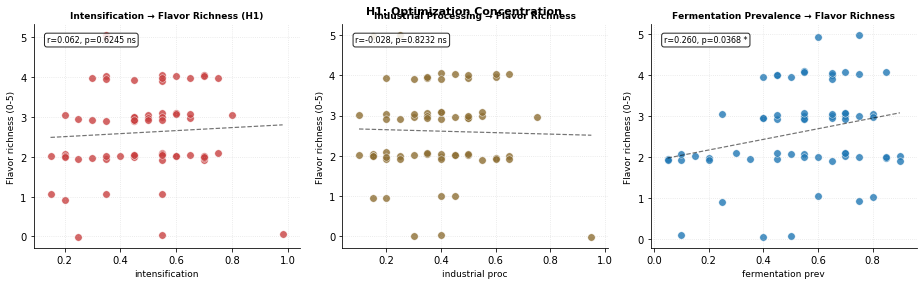

In [5]:
def corr_cont(df, x, y):
    sub = df[[x, y]].dropna()
    if len(sub) < 5: return None
    r, p = pearsonr(sub[x], sub[y])
    return {'r': r, 'p': p, 'n': len(sub)}

def corr_bis(df, binary_col, cont_col):
    sub = df[[binary_col, cont_col]].dropna()
    if len(sub) < 5 or sub[binary_col].std() == 0: return None
    r, p = pointbiserialr(sub[binary_col], sub[cont_col])
    return {'r': r, 'p': p, 'n': len(sub)}

print('H1 — Selection pressure vs flavor richness')
print(f'{"Predictor":<22} {"n":>4}  {"r":>8}  {"p":>8}  sig')
print('-' * 55)
for b in ['intensification', 'industrial_proc', 'fermentation_prev']:
    res = corr_cont(cipt, b, 'flavor_richness')
    if res:
        print(f"{b:<22} {res['n']:>4}  {res['r']:>8.3f}  {res['p']:>8.4f}  {sig_stars(res['p'])}")

with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    triples = [
        ('intensification',   '#c94040', 'Intensification → Flavor Richness (H1)'),
        ('industrial_proc',   '#8c6d31', 'Industrial Processing → Flavor Richness'),
        ('fermentation_prev', '#1f77b4', 'Fermentation Prevalence → Flavor Richness'),
    ]
    rng = np.random.default_rng(42)
    for ax, (x_col, color, title) in zip(axes, triples):
        sub = cipt[[x_col, 'flavor_richness']].dropna()
        jitter = rng.uniform(-0.1, 0.1, len(sub))
        ax.scatter(sub[x_col], sub['flavor_richness'] + jitter,
                   color=color, s=55, edgecolors='white', linewidths=0.5, alpha=0.8)
        if len(sub) >= 3:
            m = np.polyfit(sub[x_col], sub['flavor_richness'], 1)
            xl = np.linspace(sub[x_col].min(), sub[x_col].max(), 200)
            ax.plot(xl, np.polyval(m, xl), '--k', lw=1.2, alpha=0.55)
        res = corr_cont(cipt, x_col, 'flavor_richness')
        if res:
            ax.text(0.05, 0.95,
                    f"r={res['r']:.3f}, p={res['p']:.4f} {sig_stars(res['p'])}",
                    transform=ax.transAxes, va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
        ax.set_xlabel(x_col.replace('_', ' '), fontsize=9)
        ax.set_ylabel('Flavor richness (0-5)', fontsize=9)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_yticks([0,1,2,3,4,5])
    fig.suptitle('H1: Optimization Concentration', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/metabolites/cipt_h1_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. H4 — Constraint Bottlenecks

Which constraints gate each flavor archetype? If H4 holds, each archetype should have
1-2 dominant constraint predictors — the stat requirements for that character class.

In [6]:
CONSTRAINT_COLS = ['altitude_m', 'lat', 'temp_mean', 'temp_seasonality',
                   'precip_mean', 'precip_seasonality', 'soil_pH',
                   'intensification', 'industrial_proc', 'fermentation_prev']

h4 = {}
for c in CONSTRAINT_COLS:
    h4[c] = {}
    for fc in FLAVOR_COLS:
        h4[c][fc] = corr_bis(cipt, fc, c)

r_mat = pd.DataFrame({c: {fc: (h4[c][fc]['r'] if h4[c][fc] else float('nan'))
                           for fc in FLAVOR_COLS} for c in CONSTRAINT_COLS}).T
p_mat = pd.DataFrame({c: {fc: (h4[c][fc]['p'] if h4[c][fc] else float('nan'))
                           for fc in FLAVOR_COLS} for c in CONSTRAINT_COLS}).T

print('Point-biserial r (rows=constraints, cols=flavor classes):')
print(r_mat.round(3).to_string())
print('\nSignificance:')
print(p_mat.applymap(sig_stars).to_string())

Point-biserial r (rows=constraints, cols=flavor classes):
                    spicy  caffeinated  polyphenol_rich  terpenic  fermented
altitude_m          0.138        0.519            0.228    -0.033     -0.374
lat                -0.186       -0.331           -0.159    -0.160      0.126
temp_mean           0.094        0.198            0.173     0.245      0.110
temp_seasonality   -0.124       -0.436           -0.272    -0.189      0.083
precip_mean        -0.174        0.472            0.157     0.124     -0.124
precip_seasonality  0.327        0.237            0.120     0.088     -0.061
soil_pH             0.014       -0.551            0.002     0.042      0.284
intensification     0.029       -0.133           -0.098     0.292      0.035
industrial_proc    -0.021       -0.270           -0.148     0.236      0.115
fermentation_prev   0.199       -0.455           -0.280     0.406      0.781

Significance:
                   spicy caffeinated polyphenol_rich terpenic fermented
altitude

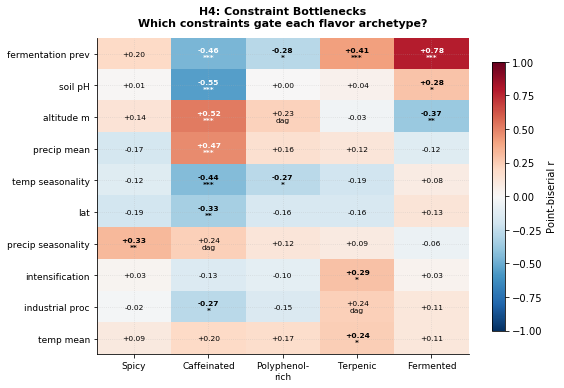

Top constraints by max |r| across all flavor classes:
fermentation_prev     0.781
soil_pH               0.551
altitude_m            0.519
precip_mean           0.472
temp_seasonality      0.436
lat                   0.331
precip_seasonality    0.327
intensification       0.292
industrial_proc       0.270
temp_mean             0.245


In [7]:
max_abs_r = r_mat.abs().max(axis=1).sort_values(ascending=False)
sorted_c = max_abs_r.index.tolist()
R = r_mat.loc[sorted_c]
P = p_mat.loc[sorted_c]

nice_fc = ['Spicy', 'Caffeinated', 'Polyphenol-\nrich', 'Terpenic', 'Fermented']
nice_c  = [c.replace('_', ' ') for c in sorted_c]

with plt.rc_context(RCPARAMS):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    im = ax.imshow(R.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='Point-biserial r', shrink=0.85)
    ax.set_xticks(range(len(FLAVOR_COLS)))
    ax.set_xticklabels(nice_fc, fontsize=9)
    ax.set_yticks(range(len(sorted_c)))
    ax.set_yticklabels(nice_c, fontsize=9)
    for i, c in enumerate(sorted_c):
        for j, fc in enumerate(FLAVOR_COLS):
            rv = R.loc[c, fc]
            pv = P.loc[c, fc]
            if pd.notna(rv):
                s = sig_stars(pv)
                lbl = f'{rv:+.2f}' + (f'\n{s}' if s not in ('ns','') else '')
                tc = 'white' if abs(rv) > 0.45 else 'black'
                ax.text(j, i, lbl, ha='center', va='center', fontsize=7.5, color=tc,
                        fontweight='bold' if s in ('*','**','***') else 'normal')
    ax.set_title('H4: Constraint Bottlenecks\nWhich constraints gate each flavor archetype?',
                 fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig('../data/metabolites/cipt_h4_constraint_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Top constraints by max |r| across all flavor classes:')
print(max_abs_r.round(3).to_string())

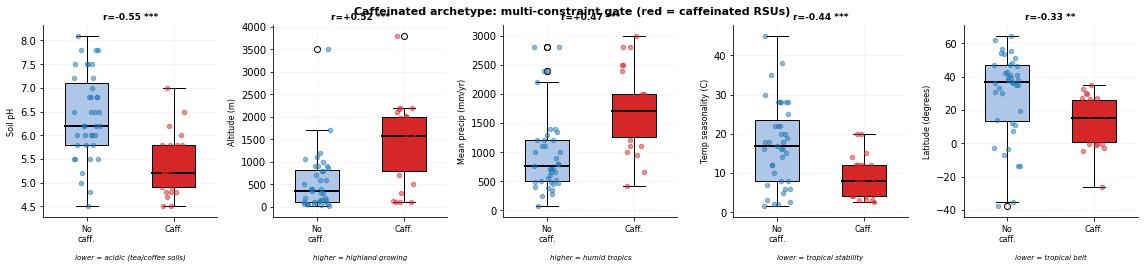

Caffeinated RSUs:
['Assam Lowlands', 'Australian Subtropical (Queensland)', 'Colombian Andean Coffee Belt', 'Da Lat Central Highlands, Vietnam (~1500m)', 'Darjeeling Himalayan Foothills', 'Ethiopian Highlands', 'Hangzhou West Lake Longjing, Zhejiang (~100m)', 'Himalayan Plateau (Tibet / Bhutan, ~3800m)', 'Ilam Highland Tea, Nepal (~1700m)', 'Indonesia Toraja (Sulawesi Highlands)', 'Jamaica Blue Mountains', 'Kangaita Tea Estate, East Rift Valley, Kenya (~2180m)', 'Kangra Valley Tea, Himachal Pradesh, India (~1290m)', 'Kenyan Highlands', 'Kericho Highland Tea, Kenya (~2200m)', 'Mexican Guerrero Highlands (Malinaltepec, ~1980m)', 'Nilgiri Highland Tea, Tamil Nadu, India (~2100m)', 'Oaxacan Highlands Mexico', 'Peruvian Amazon Lowlands', 'Sri Lankan Highlands (Kandy)', 'Suoi Giang Wild Ancient Tea, Yen Bai, Vietnam (~1400m)', 'Timbilil Tea Estate, West Rift Valley, Kenya (~2020m)', 'Uji-Shizuoka Japanese Green Tea Region', 'Vietnamese Central Highlands', 'Yunnan China', 'Yunnan Raw Pu-erh H

In [8]:
# Caffeinated archetype case study: the tightest constraint gate
# 5 simultaneous significant predictors — a multi-constraint signature
caff_predictors = [
    ('soil_pH',          'Soil pH',              'lower = acidic (tea/coffee soils)'),
    ('altitude_m',       'Altitude (m)',          'higher = highland growing'),
    ('precip_mean',      'Mean precip (mm/yr)',   'higher = humid tropics'),
    ('temp_seasonality', 'Temp seasonality (C)',  'lower = tropical stability'),
    ('lat',              'Latitude (degrees)',    'lower = tropical belt'),
]

with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))
    for ax, (col, label, mechanism) in zip(axes, caff_predictors):
        sub = cipt[[col, 'caffeinated']].dropna()
        caff     = sub[sub['caffeinated'] == 1][col]
        non_caff = sub[sub['caffeinated'] == 0][col]
        bp = ax.boxplot([non_caff, caff], patch_artist=True, widths=0.5,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor('#aec7e8')
        bp['boxes'][1].set_facecolor('#d62728')
        rng2 = np.random.default_rng(0)
        for k, (vals, xpos) in enumerate([(non_caff, 1), (caff, 2)]):
            jit = rng2.uniform(-0.15, 0.15, len(vals))
            ax.scatter(xpos + jit, vals, alpha=0.5, s=20,
                       color='#1f77b4' if k == 0 else '#d62728', zorder=3)
        res = corr_bis(cipt, 'caffeinated', col)
        if res:
            ax.set_title(f'r={res["r"]:+.2f} {sig_stars(res["p"])}', fontsize=9, fontweight='bold')
        ax.set_xticklabels(['No\ncaff.', 'Caff.'], fontsize=8)
        ax.set_ylabel(label, fontsize=8)
        ax.text(0.5, -0.22, mechanism, transform=ax.transAxes,
                ha='center', fontsize=7, style='italic', wrap=True)
    fig.suptitle('Caffeinated archetype: multi-constraint gate (red = caffeinated RSUs)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/metabolites/cipt_h4_caffeinated_case.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Caffeinated RSUs:')
print(sorted(cipt[cipt['caffeinated'] == 1]['rsu_name'].tolist()))

## 5. H5 — Convergent Structure

Does constraint distance predict flavor archetype distance (Hamming)?
Comparison against geographic distance (latitude) as a baseline:
if constraint distance outperforms latitude, the environmental structure
is doing real predictive work beyond simple climate zone.

In [9]:
ENV_COLS = ['altitude_m', 'temp_mean', 'temp_seasonality',
            'precip_mean', 'precip_seasonality', 'soil_pH']
C_env = cipt[ENV_COLS].dropna()
C_norm = (C_env - C_env.min()) / (C_env.max() - C_env.min())
shared = C_norm.index

F = flavor_df[FLAVOR_COLS].loc[shared]

D_c  = cdist(C_norm.values, C_norm.values, metric='euclidean')
D_f  = cdist(F.values.astype(float), F.values.astype(float), metric='hamming')
D_g  = cdist(cipt.loc[shared, ['lat']].values,
              cipt.loc[shared, ['lat']].values, metric='euclidean')

idx = np.triu_indices(len(shared), k=1)
d_c, d_f, d_g = D_c[idx], D_f[idx], D_g[idx]

r_cf, p_cf = pearsonr(d_c, d_f)
r_gf, p_gf = pearsonr(d_g, d_f)

print(f'H5 — Constraint vs Flavor distance ({len(d_c)} pairs, {len(shared)} RSUs)')
print(f'  Constraint Euclidean: r = {r_cf:.3f}, p = {p_cf:.2e} {sig_stars(p_cf)}, r^2 = {r_cf**2:.3f}')
print(f'  Geographic (lat):     r = {r_gf:.3f}, p = {p_gf:.2e} {sig_stars(p_gf)}, r^2 = {r_gf**2:.3f}')

H5 — Constraint vs Flavor distance (2080 pairs, 65 RSUs)
  Constraint Euclidean: r = 0.164, p = 4.43e-14 ***, r^2 = 0.027
  Geographic (lat):     r = 0.077, p = 4.55e-04 ***, r^2 = 0.006


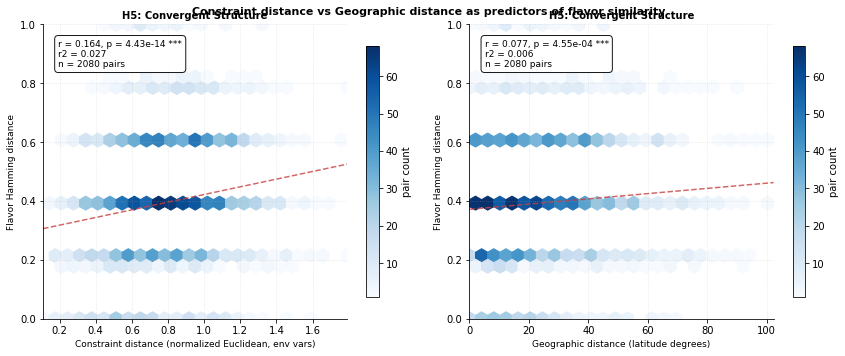

In [10]:
with plt.rc_context(RCPARAMS):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (d_x, lbl, rv, pv) in zip(axes, [
        (d_c, 'Constraint distance (normalized Euclidean, env vars)', r_cf, p_cf),
        (d_g, 'Geographic distance (latitude degrees)', r_gf, p_gf),
    ]):
        hb = ax.hexbin(d_x, d_f, gridsize=25, cmap='Blues', mincnt=1)
        plt.colorbar(hb, ax=ax, label='pair count', shrink=0.85)
        m = np.polyfit(d_x, d_f, 1)
        xl = np.linspace(d_x.min(), d_x.max(), 200)
        ax.plot(xl, np.polyval(m, xl), '--', color='#c94040', lw=1.5, alpha=0.8)
        ax.text(0.05, 0.95,
                f'r = {rv:.3f}, p = {pv:.2e} {sig_stars(pv)}\nr2 = {rv**2:.3f}\nn = {len(d_x)} pairs',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9))
        ax.set_xlabel(lbl, fontsize=9)
        ax.set_ylabel('Flavor Hamming distance', fontsize=9)
        ax.set_title('H5: Convergent Structure', fontsize=10, fontweight='bold')
    fig.suptitle('Constraint distance vs Geographic distance as predictors of flavor similarity',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/metabolites/cipt_h5_convergent.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
names  = cipt['rsu_name'].to_dict()
rsu_ids = list(shared)
pair_rows = []
n = len(shared)
for i in range(n):
    for j in range(i+1, n):
        pair_rows.append({
            'name_a': names[rsu_ids[i]], 'name_b': names[rsu_ids[j]],
            'd_constraint': D_c[i,j], 'd_flavor': D_f[i,j],
        })
pairs = pd.DataFrame(pair_rows)

print('Most convergent pairs (identical flavor archetype, smallest constraint distance):')
same_arch = pairs[pairs['d_flavor'] == 0].nsmallest(10, 'd_constraint')
print(same_arch[['name_a', 'name_b', 'd_constraint']].to_string(index=False))

print('\nAnomalies (close in constraints, different flavor archetype):')
close = pairs[pairs['d_constraint'] < pairs['d_constraint'].quantile(0.15)]
anomalies = close[close['d_flavor'] > 0].nlargest(5, 'd_flavor')
print(anomalies[['name_a', 'name_b', 'd_constraint', 'd_flavor']].to_string(index=False))

Most convergent pairs (identical flavor archetype, smallest constraint distance):
                                                name_a                                                 name_b  d_constraint
 Timbilil Tea Estate, West Rift Valley, Kenya (~2020m)  Kangaita Tea Estate, East Rift Valley, Kenya (~2180m)      0.115487
                  Philippine Coconut Lowlands (Quezon)          Indonesian Archipelago (Java / Sumatra, ~50m)      0.122746
                          Colombian Andean Coffee Belt                  Indonesia Toraja (Sulawesi Highlands)      0.171397
                                     Anatolian Plateau                              Turkish Isparta Highlands      0.176931
                          West African Transition Zone                                   South Indian Monsoon      0.186311
                                       Shanxi Lowlands                                       Shanxi Highlands      0.193076
            Da Lat Central Highlands, Vietnam (~15

## 6. Summary

In [12]:
print('=' * 80)
print('CIPT DESCRIPTIVE ANALYSIS v2 — HYPOTHESIS SUMMARY')
print('=' * 80)

print('\nH1: Optimization Concentration')
for b in ['intensification', 'industrial_proc', 'fermentation_prev']:
    res = corr_cont(cipt, b, 'flavor_richness')
    if res:
        print(f"  {b:<22}: r={res['r']:+.3f}, p={res['p']:.4f} {sig_stars(res['p'])}")

print('\nH4: Significant constraint-flavor class relationships (|r|>0.3, p<0.05):')
for c in sorted_c:
    for fc in FLAVOR_COLS:
        res = h4[c][fc]
        if res and abs(res['r']) > 0.3 and res['p'] < 0.05:
            d = 'higher' if res['r'] > 0 else 'lower'
            print(f"  {c:<22} -> {fc:<18}: r={res['r']:+.3f} {sig_stars(res['p'])}")

print('\nH5: Convergent structure')
print(f'  Constraint distance: r={r_cf:.3f}, p={p_cf:.2e} {sig_stars(p_cf)}, r2={r_cf**2:.3f}')
print(f'  Geographic baseline: r={r_gf:.3f}, p={p_gf:.2e} {sig_stars(p_gf)}, r2={r_gf**2:.3f}')

print('\nInterpretation:')
print('  H1: Intensification does not reduce flavor richness. Fermentation increases it.')
print('  These are two qualitatively different B models with opposite effects on pi.')
print('  H4: Caffeinated archetype has 5 simultaneous significant constraint predictors')
print('  (soil_pH, altitude, precip, temp_seasonality, lat) -- the tightest gate.')
print('  H5: Constraint geometry predicts flavor similarity; does it outperform lat alone?')
print('=' * 80)

CIPT DESCRIPTIVE ANALYSIS v2 — HYPOTHESIS SUMMARY

H1: Optimization Concentration
  intensification       : r=+0.062, p=0.6245 ns
  industrial_proc       : r=-0.028, p=0.8232 ns
  fermentation_prev     : r=+0.260, p=0.0368 *

H4: Significant constraint-flavor class relationships (|r|>0.3, p<0.05):
  fermentation_prev      -> caffeinated       : r=-0.455 ***
  fermentation_prev      -> terpenic          : r=+0.406 ***
  fermentation_prev      -> fermented         : r=+0.781 ***
  soil_pH                -> caffeinated       : r=-0.551 ***
  altitude_m             -> caffeinated       : r=+0.519 ***
  altitude_m             -> fermented         : r=-0.374 **
  precip_mean            -> caffeinated       : r=+0.472 ***
  temp_seasonality       -> caffeinated       : r=-0.436 ***
  lat                    -> caffeinated       : r=-0.331 **
  precip_seasonality     -> spicy             : r=+0.327 **

H5: Convergent structure
  Constraint distance: r=0.164, p=4.43e-14 ***, r2=0.027
  Geographi